In [1]:

import pandas as pd


mental_health_dataset = pd.read_csv('Combined Data.csv')

columns_to_remove = ['Unnamed: 0']
for col in columns_to_remove:
    if col in mental_health_dataset.columns:
        mental_health_dataset.drop(columns=[col], inplace=True)


mental_health_dataset.dropna(subset=['statement'], inplace=True)


df = mental_health_dataset.reset_index(drop=True)


print(">>> DATASET METRICS <<<")
print(f"Total Valid Records: {len(df)}")
print(f"Total Variables: {len(df.columns)}\n")

print(">>> PSYCHOLOGICAL CLASS DISTRIBUTIONS <<<")
print(df['status'].value_counts(), "\n")

print(">>> DATA SNIPPET <<<")
display(df.head(4))

>>> DATASET METRICS <<<
Total Valid Records: 52681
Total Variables: 2

>>> PSYCHOLOGICAL CLASS DISTRIBUTIONS <<<
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64 

>>> DATA SNIPPET <<<


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety


In [2]:
import re
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords', quiet=True)


irrelevant_terms = set(stopwords.words('english'))

def refine_psychological_text(raw_sentence):
    """
    This function cleans social media text by making it lowercase,
    removing symbols/numbers, and dropping irrelevant English words.
    """
    
    text_data = str(raw_sentence).lower()
    
    
    text_data = re.sub(r'[^a-z\s]', '', text_data)
    
   
    word_tokens = text_data.split()
    
    
    meaningful_words = [term for term in word_tokens if term not in irrelevant_terms]
    
    
    return ' '.join(meaningful_words)

print("Sanitizing the text dataset (Please wait, this may take 1-2 minutes)")


df['processed_statement'] = df['statement'].apply(refine_psychological_text)


print("\n--- TEXT BEFORE vs AFTER ---")
display(df[['statement', 'processed_statement']].head(10))

Sanitizing the text dataset (Please wait, this may take 1-2 minutes)

--- TEXT BEFORE vs AFTER ---


,statement,processed_statement
0,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean
5,"every break, you must be nervous, like somethi...",every break must nervous like something wrong ...
6,"I feel scared, anxious, what can I do? And may...",feel scared anxious may family us protected
7,Have you ever felt nervous but didn't know why?,ever felt nervous didnt know
8,"I haven't slept well for 2 days, it's like I'm...",havent slept well days like im restless huh
9,"I'm really worried, I want to cry.",im really worried want cry


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

sentiment_vectorizer = TfidfVectorizer(max_features=10000)

print("Converting psychological text into mathematical matrices... (Please wait)")


X_feature_matrix = sentiment_vectorizer.fit_transform(df['processed_statement'])

y_target_categories = df['status']

X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(
    X_feature_matrix, 
    y_target_categories, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_target_categories
)

print("\n>>> VECTORIZATION COMPLETE <<<")
print(f"Mathematical dimensions of Training Data: {X_train_set.shape}")
print(f"Mathematical dimensions of Testing Data: {X_test_set.shape}")

Converting psychological text into mathematical matrices... (Please wait)

>>> VECTORIZATION COMPLETE <<<
Mathematical dimensions of Training Data: (42144, 10000)
Mathematical dimensions of Testing Data: (10537, 10000)


In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import pandas as pd

print(">>> INITIATING MACHINE LEARNING TRAINING PHASE <<<\n")


print("Training Model 1: Multinomial Naive Bayes...")
nb_algorithm = MultinomialNB()
nb_algorithm.fit(X_train_set, y_train_set)
nb_predictions = nb_algorithm.predict(X_test_set)
nb_acc = accuracy_score(y_test_set, nb_predictions)

nb_metrics = precision_recall_fscore_support(y_test_set, nb_predictions, average='weighted')


print("Training Model 2: Random Forest (50 Trees)...")
rf_engine = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_engine.fit(X_train_set, y_train_set)
rf_predictions = rf_engine.predict(X_test_set)
rf_acc = accuracy_score(y_test_set, rf_predictions)
rf_metrics = precision_recall_fscore_support(y_test_set, rf_predictions, average='weighted')


print("Training Model 3: Linear Support Vector Machine...")
svm_predictor = LinearSVC(random_state=42, dual=False)
svm_predictor.fit(X_train_set, y_train_set)
svm_predictions = svm_predictor.predict(X_test_set)
svm_acc = accuracy_score(y_test_set, svm_predictions)
svm_metrics = precision_recall_fscore_support(y_test_set, svm_predictions, average='weighted')


comparison_data = {
    'Model': ['Naive Bayes', 'Random Forest', 'SVM (Linear)'],
    'Accuracy': [nb_acc, rf_acc, svm_acc],
    'Precision': [nb_metrics[0], rf_metrics[0], svm_metrics[0]],
    'Recall': [nb_metrics[1], rf_metrics[1], svm_metrics[1]],
    'F1-Score': [nb_metrics[2], rf_metrics[2], svm_metrics[2]]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*60)
print(">>> FINAL RESEARCH COMPARISON TABLE <<<")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)


print("\n>>> DETAILED REPORT: NAIVE BAYES <<<")
print(classification_report(y_test_set, nb_predictions))

print("\n>>> DETAILED REPORT: RANDOM FOREST <<<")
print(classification_report(y_test_set, rf_predictions))

print("\n>>> DETAILED REPORT: SVM (WINNING MODEL) <<<")
print(classification_report(y_test_set, svm_predictions))

>>> INITIATING MACHINE LEARNING TRAINING PHASE <<<

Training Model 1: Multinomial Naive Bayes...
Training Model 2: Random Forest (50 Trees)...
Training Model 3: Linear Support Vector Machine...

>>> FINAL RESEARCH COMPARISON TABLE <<<
        Model  Accuracy  Precision   Recall  F1-Score
  Naive Bayes  0.653507   0.719663 0.653507  0.636328
Random Forest  0.712062   0.729403 0.712062  0.696688
 SVM (Linear)  0.764164   0.759157 0.764164  0.759668

>>> DETAILED REPORT: NAIVE BAYES <<<
                      precision    recall  f1-score   support

             Anxiety       0.82      0.56      0.66       768
             Bipolar       0.94      0.40      0.56       556
          Depression       0.49      0.84      0.62      3081
              Normal       0.85      0.80      0.83      3269
Personality disorder       1.00      0.04      0.07       215
              Stress       0.78      0.06      0.11       517
            Suicidal       0.71      0.46      0.56      2131

            a

>>> GENERATING PERFORMANCE VISUALIZATIONS <<<



C:\Users\91981\AppData\Local\Temp\ipykernel_15724\1634969924.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=algorithm_names, y=performance_scores, palette='mako')


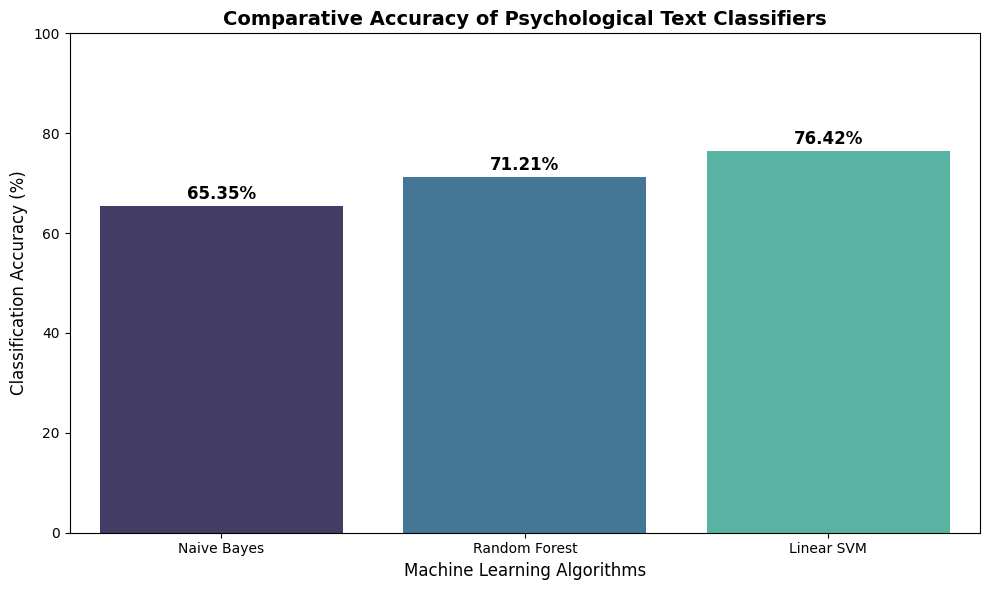

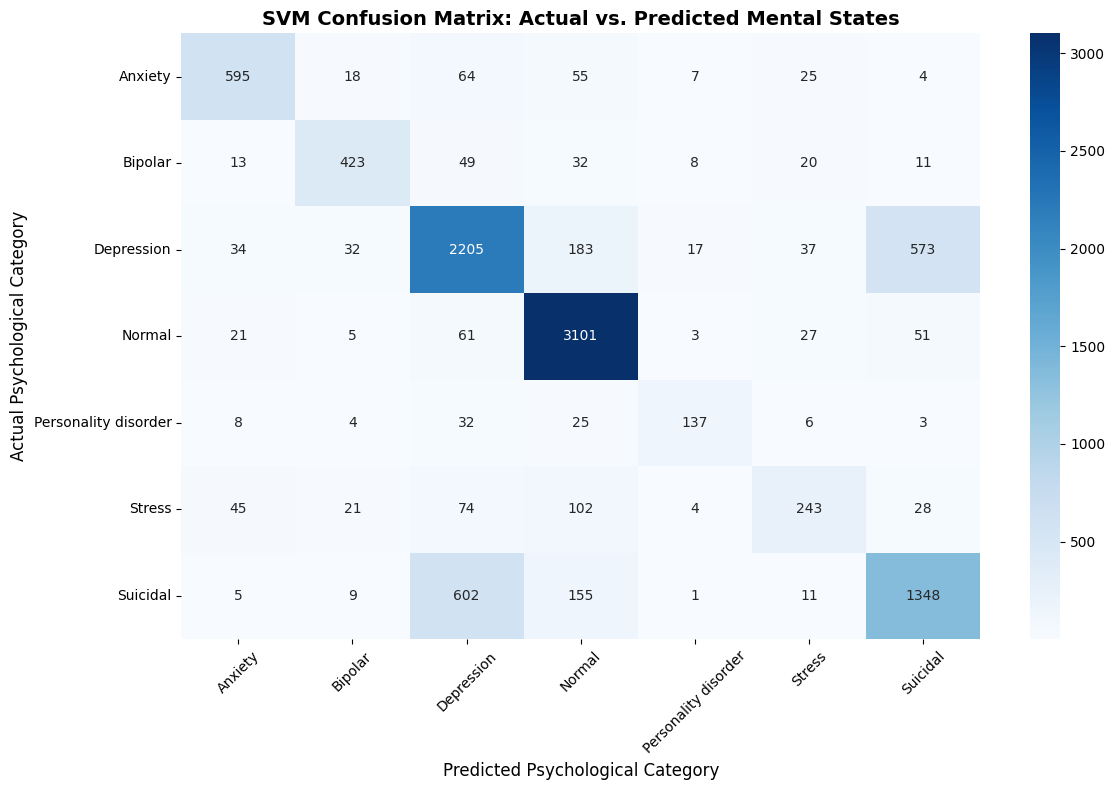

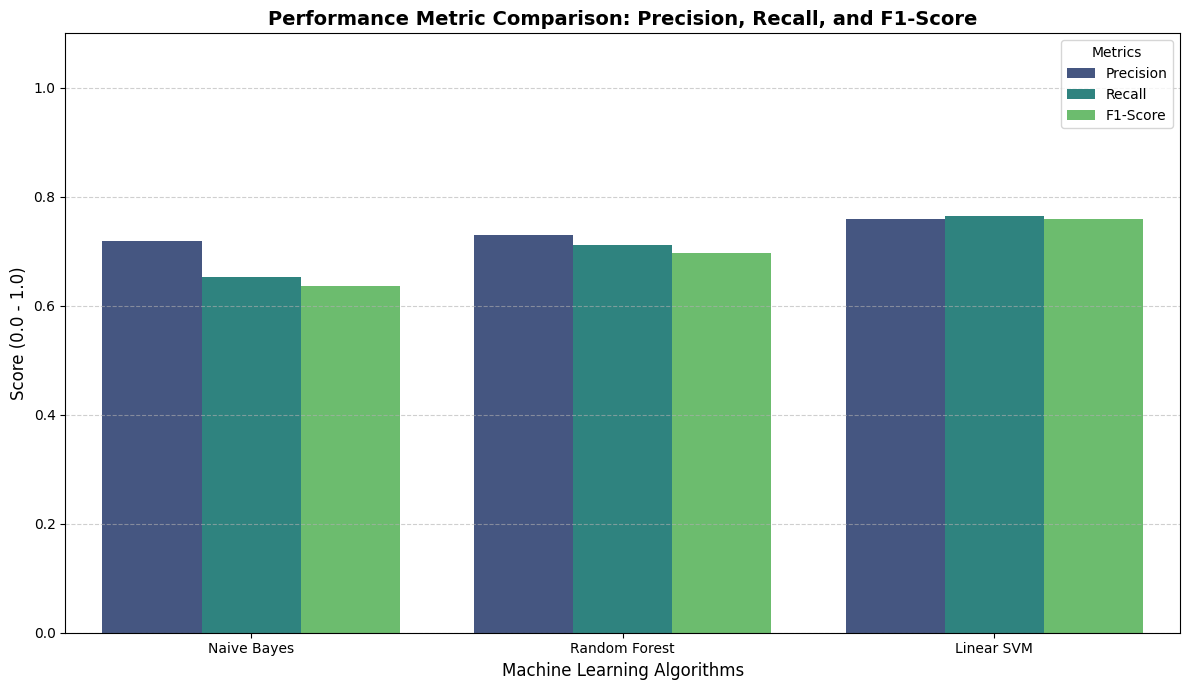

>>> PIPELINE EXECUTION COMPLETE! <<<


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(">>> GENERATING PERFORMANCE VISUALIZATIONS <<<\n")


algorithm_names = ['Naive Bayes', 'Random Forest', 'Linear SVM']
performance_scores = [
    nb_acc * 100, 
    rf_acc * 100, 
    svm_acc * 100
]

plt.figure(figsize=(10, 6))
sns.barplot(x=algorithm_names, y=performance_scores, palette='mako')

plt.title('Comparative Accuracy of Psychological Text Classifiers', fontsize=14, fontweight='bold')
plt.ylabel('Classification Accuracy (%)', fontsize=12)
plt.xlabel('Machine Learning Algorithms', fontsize=12)
plt.ylim(0, 100) 

for index, score in enumerate(performance_scores):
    plt.text(index, score + 1.5, f"{score:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

svm_conf_matrix = confusion_matrix(y_test_set, svm_predictions)
category_labels = svm_predictor.classes_

plt.figure(figsize=(12, 8))

sns.heatmap(
    svm_conf_matrix, 
    annot=True,        
    fmt='d',           
    cmap='Blues',      
    xticklabels=category_labels, 
    yticklabels=category_labels
)

plt.title('SVM Confusion Matrix: Actual vs. Predicted Mental States', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Psychological Category', fontsize=12)
plt.ylabel('Actual Psychological Category', fontsize=12)
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()


metrics_comparison_data = {
    'Algorithm': ['Naive Bayes', 'Random Forest', 'Linear SVM'],
    'Precision': [nb_metrics[0], rf_metrics[0], svm_metrics[0]],
    'Recall': [nb_metrics[1], rf_metrics[1], svm_metrics[1]],
    'F1-Score': [nb_metrics[2], rf_metrics[2], svm_metrics[2]]
}


import pandas as pd
df_metrics_plot = pd.DataFrame(metrics_comparison_data).melt(id_vars='Algorithm', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))

sns.barplot(data=df_metrics_plot, x='Algorithm', y='Score', hue='Metric', palette='viridis')

plt.title('Performance Metric Comparison: Precision, Recall, and F1-Score', fontsize=14, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Machine Learning Algorithms', fontsize=12)
plt.ylim(0, 1.1) 
plt.legend(title='Metrics', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(">>> PIPELINE EXECUTION COMPLETE! <<<")